# 📗 [커머스] H&M 데이터 분석 — 01 데이터 이해 & 전처리

> 엔코아 AI캠퍼스 · 데이터 분석 & AI 머신러닝 캠프 · 10일차 종합 프로젝트

**오늘은 강사가 앞에서 풀어 주지 않습니다.** 이 노트북은 프로젝트의 **중심 파트**입니다 — day06~09 에 배운 도구로 **문제를 정의**하고, 데이터의 함정을 눈으로 확인한 뒤, **여러분이 정한 규칙**으로 정제본을 만들어 저장합니다.

> ⚠️ **이 노트북에는 실행할 코드가 미리 들어 있지 않습니다.** 각 절이 **무엇을 해야 하는지**와 **어떤 도구를 쓰는지**를 알려 주니, 코드는 그것을 보고 **스스로 쓰세요.** 지침마다 **확인 기준**(무엇이 나오면 맞는지)이 함께 적혀 있어, 강사가 없어도 스스로 맞는지 확인하며 나아갈 수 있습니다.

> ⚠️ **중요**: 이 노트북 맨 마지막 셀이 `output/hm_clean.csv` 를 저장합니다. **다음 두 노트북(EDA·통계)이 이 파일을 그대로 이어받으므로**, 이 노트북을 끝까지 실행해 저장까지 마쳐야 다음 단계로 넘어갈 수 있습니다.

## 오늘의 파일
| 파일 | 내용 |
|---|---|
| **`01_데이터이해_전처리.ipynb`** | **지금 이 파일** — 문제 정의 + 데이터 이해 + 함정 확인 + 전처리 규칙 수립 + 정제본 저장 |
| `02_데이터_EDA.ipynb` | 이 노트북이 저장한 정제본으로 EDA·시각화 |
| `03_데이터_통계.ipynb` | 통계 분석 + 인사이트 리포트 |

## 이 노트북의 흐름
| 장 | 내용 | 형식 |
|---|---|---|
| 1장 | 문제 정의 — 비즈니스 질문부터 분석 계획까지 | 서술 |
| 2장 | 데이터 이해 — 3테이블 구조 파악 | 지침 + 코드 + 자가채점 |
| 3장 | 함정 확인 — 이상치·결측 미리보기 | 지침 + 코드 |
| 4장 | 전처리 규칙 수립 — 결정 기록표 | 서술 |
| 5장 | 테이블 결합 | 지침 + 코드 + 자가채점 |
| 6장 | 전처리 규칙 적용 & 파생변수 — 처리 로그 | 코드 |
| 7장 | 정제본 저장 | 지침 + 코드 |

## 세 노트북이 어떻게 이어지는가
이 프로젝트 전체가 **한 문제를 7단계로 꿰는 과정**입니다. 지금 여러분은 **1~3단계**에 있습니다 — 색이 곧 노트북 번호입니다.

![프로젝트 흐름도](images/프로젝트_흐름도.png)

**자가채점 안내** — 이 노트북은 **원본 3테이블 shape** 와 **조인 직후 행수**, 두 곳만 사실 확인으로 채점합니다. 문제 정의 서술과 결측·이상치 처리 규칙, 최종 정제본의 행수는 **채점하지 않습니다** — 규칙에 따라 숫자가 달라지는 것이 정상입니다.

**직접 작성 — 라이브러리와 한글 폰트 준비**

**할 일**: 이 노트북 전체에서 쓸 라이브러리를 불러오고, 그래프에 한글이 깨지지 않게 폰트를 설정하세요.

**왜**: 뒤의 모든 셀이 여기서 정한 **별칭**(`pd`·`np`·`plt`·`sns`)을 그대로 씁니다 — 별칭을 다르게 쓰면 이후 지침의 코드 이름이 전부 어긋납니다.

**확인 기준**: 출력은 없습니다. 에러 없이 끝나면 통과이고, 3장에서 그래프를 그렸을 때 제목의 한글이 □ 로 보이지 않으면 폰트까지 제대로 된 것입니다.

**함정**: `sns.set_theme()` 은 matplotlib 의 `font.family` 를 자기 기본값으로 **되돌립니다.** 그래서 `set_theme` 에 `font=` 로 폰트를 함께 넘기거나, `set_theme` 을 먼저 부르고 `rcParams` 설정을 나중에 해야 합니다. 순서를 반대로 하면 폰트 설정이 조용히 사라져 한글이 깨집니다.

In [1]:
# ── 쓸 도구 ─────────────────────────────────────────
#   import 할 것: pandas -> pd, numpy -> np, matplotlib.pyplot -> plt, seaborn -> sns.
#     여기에 표준 라이브러리 os(폴더 만들기 — 7장에서 씁니다)와 platform(실행 중인 OS 판별)도
#     함께.
#   상품 테이블은 컬럼이 25개라 기본 설정에서는 가운데가 ... 로 접힙니다.
#     pd.set_option('display.max_columns', 40) 으로 넉넉히 열어 두세요.
#   한글 폰트 이름은 OS 마다 다릅니다: Windows Malgun Gothic · macOS AppleGothic ·
#     Linux(Colab 등) NanumGothic. platform.system() 이 각각 'Windows'·'Darwin'·그 외를
#     돌려주니 분기해서 고른 이름을 변수(예: KOREAN_FONT)에 담아 두면 아래 두 곳에서 재사용할
#     수 있습니다.
#   폰트 적용: plt.rcParams['font.family'] 에 그 폰트 이름을,
#     plt.rcParams['axes.unicode_minus'] 에 False 를 넣습니다(음수 부호가 깨져 □ 로 나오는
#     것을 막습니다).
#   seaborn 도 쓰므로 테마와 폰트를 함께 지정하세요 — sns.set_theme(style='whitegrid',
#     font=..., rc={'axes.unicode_minus': False}).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import os

pd.set_option('display.max_columns', 40)

# 한글 폰트
if platform.system() == 'Windows':
    KOREAN_FONT = 'Malgun Gothic'
    FONT_PATH = 'C:/Windows/Fonts/malgun.ttf'
elif platform.system() == 'Darwin':          # macOS
    KOREAN_FONT = 'AppleGothic'
    FONT_PATH = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
else:                                        # Linux (Colab 등)
    KOREAN_FONT = 'NanumGothic'
    FONT_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

plt.rcParams['font.family'] = KOREAN_FONT
plt.rcParams['axes.unicode_minus'] = False

sns.set_theme(style='whitegrid', font='Malgun Gothic', rc={'axes.unicode_minus': False})


## 1장. 문제 정의
**이 절에서 할 일**: 데이터를 만지기 전에 무엇을 밝힐지 정합니다 — 이후 모든 선택(어떤 컬럼을 볼지, 어떤 그래프를 그릴지)이 여기서 세운 방향을 따라갑니다. 좋은 분석은 좋은 질문에서 시작합니다.

### 여러분에게 맡겨진 상황
여러분은 **H&M 데이터 분석 팀의 데이터 애널리스트**입니다. H&M 은 1947년에 설립돼 전 세계 70여 개국에서 의류·홈·뷰티 상품을 파는 패션 기업이고, 여러분에게 주어진 것은 그 고객·거래·상품 기록입니다. 서비스 현황을 점검해 **고객 경험 개선과 매출 성장 전략**에 쓸 결과물을 만들어야 합니다.

요청받은 것은 네 가지입니다 — 이 프로젝트 세 노트북이 이 네 가지를 나눠 맡습니다.

| # | 요청사항 | 담당 |
| --- | --- | --- |
| 1 | 고객·매출 데이터를 탐색해 **서비스 현황을 시각화**해 주세요 | 02 |
| 2 | **채널·상품군·고객 속성별 매출 특징**을 분석해 주세요 | 02·03 |
| 3 | **이상치·결측치 처리 과정을 포함한 EDA 결과**를 제출해 주세요 | **01(이 노트북)**·02 |
| 4 | **분석 결과와 인사이트(전략)** 를 제공해 주세요 | 03 |

> 이 노트북이 맡은 3번이 나머지의 **바탕**입니다. 여기서 만든 정제본이 잘못되면 02·03 의 그래프와 통계가 전부 잘못된 데이터를 보게 됩니다.

### 1-1. 비즈니스 질문 -> 분석 질문 -> 데이터 질문
막연한 질문은 그대로는 분석할 수 없습니다. 세 단계로 좁혀야 합니다.

1. **비즈니스 질문** — 경영진이 던질 법한 막연한 질문("매출을 어떻게 늘릴까?")
2. **분석 질문** — 측정 가능하게 좁힌 질문("어떤 연령대·채널 조합이 결제금액에 가장 크게 기여하는가?")
3. **데이터 질문** — 정확히 어떤 컬럼·집계로 답할지 못박은 질문("`age_group`·`sales_channel_id` 로 나눠 `price` 합계·평균을 비교하면 어느 조합이 가장 큰가?")

> 위 예시처럼, 3단계를 내려갈수록 **컬럼 이름이 등장할 만큼 구체적**이어야 합니다.

### 1-2. 좋은 질문 / 나쁜 질문

| 나쁜 질문 | 왜 나쁜가 | 좋은 질문으로 고치면 |
| --- | --- | --- |
| "매출이 얼마인가?" | 답이 나와도 결정으로 안 이어짐("그래서 뭘 할 건데?"가 안 생김) | "어느 축(연령·채널·상품군)으로 갈랐을 때 결제금액 차이가 가장 큰가?" |
| "고객들은 어떤가?" | 데이터로 답하기엔 너무 막연함 | "연령대별 평균 결제금액과 구매 빈도는 어떻게 다른가?" |
| "왜 특정 상품이 인기 있나?" | 이 데이터엔 '이유'를 설명할 변수가 없음(관찰 데이터의 한계) | "어떤 상품군이 결제금액 상위인가?"(원인이 아니라 관찰) |

**좋은 질문의 조건**: 데이터에 있는 컬럼으로 답할 수 있다 · 답이 나오면 누군가 결정할 수 있다 · "얼마인가" 보다 "**어느 축으로 갈랐을 때** 차이가 큰가" 가 낫다.

### 1-3. 이해관계자를 정하면 질문이 달라진다
같은 데이터라도 **누구를 위한 분석인지**에 따라 좋은 질문이 달라집니다.

| 이해관계자 | 관심사 | 이 관점의 질문 예시 |
| --- | --- | --- |
| 마케팅팀 | 고객 세그먼트별 프로모션 | 어떤 연령대·멤버십 상태가 프로모션에 반응할 잠재력이 큰가? |
| 상품기획팀 | 인기 상품군·색상 트렌드 | 어떤 제품군·색상이 결제금액 상위를 차지하는가? |
| 경영진 | 채널 구조와 성장 가능성 | 온라인·오프라인 채널별 결제금액 비중과 평균 단가는 어떻게 다른가? |

### 1-4. 가설 쓰는 법 — day09 의 H0/H1 로 연결
가설은 "~일 것이다" 처럼 **데이터로 참·거짓을 가릴 수 있는 문장**이어야 합니다. 이 문장은 나중에 `03_데이터_통계` 에서 배운 통계적 가설검정으로 다시 쓸 수 있습니다 — **귀무가설 H0**(차이가 없다·효과가 없다)과 **대립가설 H1**(차이가 있다)로요.

> 예시: 서술 가설 "연령대가 높을수록 평균 결제금액이 높을 것이다"
> - **H0**: 연령대별 평균 결제금액에 차이가 없다.
> - **H1**: 연령대별 평균 결제금액에 차이가 있다.

지금은 서술만 하면 됩니다 — 실제 검정은 `03_데이터_통계` 의 몫입니다.

**어떤 질문이 어떤 검정으로 가는가** — 아래 네 줄은 `03_데이터_통계` 의 통계 미션 A·B·C·E 와 같은 질문입니다. 지금 세우는 가설이 나중에 어디로 이어지는지 미리 봐 두세요. **질문의 변수 유형(③)이 검정을 결정합니다** — 검정을 먼저 고르는 것이 아닙니다.

![비즈니스 질문을 통계 질문으로 바꾸는 법](images/비즈니스질문_통계가설_매핑.png)

### 1-5. 분석 계획표 (직접 채우세요)
핵심 질문마다 **필요한 컬럼**과 **볼 방법**을 미리 적어 두면 이후 EDA·통계에서 헤매지 않습니다. (데이터에 대한 이해와 도메인에 대한 이해 필요)

| 질문 | 필요한 컬럼 | 볼 방법(집계·그래프) | 예상 결과 |
| --- | --- | --- | --- |
| 채널별 평균 단가가 다른가? | price, sales_channel_id | groupby('sales_channel_id')['price'].mean() + 박스플롯 | 온라인(2)가 더 높을 것이다. |
| 연령대별 구매 건수 및 단가가 어떻게 다른가? | price, age | groupby('age_group').agg(['count', 'mean']) + 막대그래프 | 연령대가 높아질수록 구매건수는 줄고 단가가 높아질 것이다. |
| 시즌별로 월별 결제금액 총합이 다른가? | t_dat, price | groupby('month')['price'].sum() + 선그래프 | 7~8월 / 11~12월 결제금액 총합이 높을 것이다. |

** age_group, month 파생변수 생성 필요

### 1-6. 종합 — 비즈니스 목표·이해관계자·핵심 질문·가설 서술
**요구사항** — ① 이 분석의 **비즈니스 목표를 한 문장**으로 적고("무엇을 위해 이 분석을 하는가"), ② **이해관계자**를 하나 고르고, ③ **핵심 질문 2~3개**, ④ 각 질문의 **가설**(H0/H1 형태 포함)을 서술하세요.

> 비즈니스 목표는 질문보다 한 단계 위입니다 — 질문은 여러 개지만 목표는 하나이고, 목표가 질문을 고르는 기준이 됩니다. 위 "여러분에게 맡겨진 상황" 의 네 요청사항에서 출발하세요.

**여기까지 되면 통과**: 비즈니스 목표 1문장 + 이해관계자 1개 + 핵심질문 2~3개 + 가설(H0/H1 포함) + 분석 계획표가 채워져 있으면 됩니다. 내용은 사람마다 달라도 됩니다.

*(여기에 비즈니스 목표 1문장, 이해관계자 1개, 핵심 질문 2~3개, 각 질문의 가설(H0/H1 포함)을 서술하세요)*
- 비즈니스 목표: 채널·연령대·시즌별 결제금액 패턴을 파악하여 마케팅팀의 **타겟 프로모션 전략** 수립
- 이해관계자: H&M 마케팅팀
- 핵심 질문
    - 채널별 평균 단가가 다른가?
    - 연령대별 구매 건수 및 단가가 어떻게 다른가?
    - 시즌별로 월별 결제금액 총합이 다른가?
- 가설
    - H0: 채널 간 평균 단가에 차이가 없다 / H1: 차이가 있다
    - H0: 연령대 간 평균 단가에 차이가 없다 / H1: 차이가 있다
    - H0: 월별 결제금액 총합이 균등하다 / H1: 특정 월에 치우쳐 있다

## 2장. 데이터 이해 — 3개 테이블
**이 절에서 할 일**: 세 테이블을 각각 불러와 크기·컬럼·자료형·결측을 확인합니다. **분석은 데이터를 눈으로 보는 것에서 시작합니다.** 아래 지침을 하나씩 읽고 **코드를 직접 써서** 출력을 읽으세요. 함수 이름이 기억나지 않으면 day06 교안에서 찾아보세요.

### 데이터 소스 — 출처·구성·관측단위

| 항목 | 내용 |
| --- | --- |
| **출처** | Kaggle 에 공개된 **H&M Personalized Fashion Recommendations** 데이터셋에서 뽑은 표본입니다(H&M 전체 실적이 아닙니다) |
| **구성** | CSV 3개 — 거래 `transactions_hm` · 고객 `customer_hm` · 상품 `articles_hm` |
| **기간** | **2019-01-01 ~ 2019-12-31, 딱 1년치**입니다 |
| **관측단위** | 테이블마다 다릅니다: 거래는 **구매 1건**, 고객은 **고객 1명**, 상품은 **상품 1개**가 한 행입니다. 5장에서 셋을 결합하면 관측단위가 **"고객·상품 정보가 붙은 구매 1건"** 이 됩니다 |
| **주요 변수** | 아래 컬럼 사전 참고 |

> ⚠️ **기간이 1년이라는 점을 기억하세요.** 연도 간 비교나 "몇 년에 걸친 성장 추세" 같은 이야기는 이 데이터로 할 수 없습니다. 월별·요일별 비교까지가 가능한 범위입니다.

### 테이블 관계 (ERD)
![테이블 관계 (ERD)](images/테이블_관계_ERD.png)
한 고객이 여러 번 구매하고(1:N), 한 상품이 여러 거래에 등장합니다(N:1). **거래 테이블이 중심**이고 양쪽으로 고객·상품 정보를 붙이는 구조입니다. 이 노트북에서는 세 테이블을 각각 `tr`(거래)·`cu`(고객)·`ar`(상품) 으로 부릅니다.

### 컬럼 사전
**거래 `tr` (150,500행)** — 행 = 구매 1건

| 컬럼 | 설명 |
| --- | --- |
| `t_dat` | 구매일(문자열 — 아직 날짜형이 아닙니다) |
| `customer_id` | 고객 식별자 |
| `article_id` | 상품 식별자 |
| `price` | 결제 금액 — **0~1 사이로 정규화된 상대값**(실제 범위 0 ~ 0.422, 평균 0.0276) |
| `sales_channel_id` | 판매 채널(1=오프라인, 2=온라인 — 그 외 값은 3장에서 확인) |

**고객 `cu` (95,516행)** — 행 = 고객 1명

| 컬럼 | 설명 |
| --- | --- |
| `customer_id` | 고객 식별자 |
| `age` | 나이(이상치 섞임 — 3장에서 확인) |
| `club_member_status` | 멤버십 상태(ACTIVE/PRE-CREATE/LEFT CLUB, 일부 결측) |
| `fashion_news_frequency` | 패션 뉴스 수신 빈도 |
| `FN` / `Active` | 뉴스 수신·활성 회원 플래그 |

**상품 `ar` (30,503행, 25컬럼)** — 행 = 상품 1개(주요 컬럼만)

| 컬럼 | 설명 |
| --- | --- |
| `article_id` | 상품 식별자 |
| `prod_name` | 상품명 |
| `product_group_name` | 제품군(Garment Upper body 등) |
| `colour_group_name` | 색상 그룹 |
| `index_group_name` | 타겟 그룹(Ladieswear 등) |

> ⚠️ **읽을 때 주의** — `price` 는 절대 금액이 아니라 정규화값(상대 비교용)입니다. 그리고 이 데이터엔 구매 **수량(quantity) 컬럼이 없어**, `price` 의 합계는 진짜 매출이 아니라 **"구매 단가의 총합"** 입니다. 02·03 에서 "매출"이라는 말을 쓸 때도 이 뜻으로 쓰세요 — 리포트에 그 한계를 한 줄 적어야 합니다.

> ⚠️ **발제문 서술도 데이터로 확인하세요.** 이 프로젝트 발제문에는 `price` 의 통화 단위가 **SEK(스웨덴 크로나)** 라고 적혀 있습니다. 그런데 실제 값을 보면 최대가 0.422 이고 평균이 0.0276 입니다 — 옷 한 벌 값이 0.03 크로나일 수는 없으니, 이 컬럼은 **원 통화 금액이 아니라 정규화된 상대값**입니다. 발제문·기획서에 적힌 설명이 데이터와 어긋나는 일은 실무에서 흔합니다. **주어진 문서를 그대로 믿지 말고 `describe()` 로 직접 확인하는 것**이 분석가의 첫 번째 습관입니다(3장에서 실제로 확인합니다).

**직접 작성 — 세 테이블 불러오기**

**할 일**: 아래 세 CSV 를 각각 읽어 **`tr`·`cu`·`ar`** 이라는 이름에 담고, 세 테이블의 **행수·열수·전체 결측 건수**를 한 줄씩 출력하세요.

| 변수 이름 | 파일 경로 | 내용 |
| --- | --- | --- |
| `tr` | `data/hm/transactions_hm.csv` | 거래 |
| `cu` | `data/hm/customer_hm.csv` | 고객 |
| `ar` | `data/hm/articles_hm.csv` | 상품 |

> ⚠️ **이 세 변수 이름은 반드시 지키세요.** 바로 다음 자가채점 셀과 이 노트북의 2·3·5장이 `tr`·`cu`·`ar` 를 그대로 씁니다.

**왜**: 아직 아무것도 손대지 않은 원본을 먼저 봐야, 3장에서 무엇이 함정인지 판단할 수 있습니다.

**확인 기준**

| 테이블 | 행 x 열 |
| --- | --- |
| 거래 `tr` | 150,500 x 5 |
| 고객 `cu` | 95,516 x 6 |
| 상품 `ar` | 30,503 x 25 |

다음 자가채점 셀이 이 세 값을 검사합니다.

**함정**: `.isna().sum()` 은 **컬럼별** 결측 개수를 담은 표를 돌려줍니다 — 테이블 전체 건수를 보려면 `.sum()` 을 **한 번 더** 붙여 그 표를 다시 합쳐야 합니다.

In [2]:
# ── 쓸 도구 ─────────────────────────────────────────
#   pd.read_csv(경로) · .shape((행수, 열수) 튜플) · 전체 결측 건수는 .isna().sum().sum().\

tr = pd.read_csv('./data/hm/transactions_hm.csv')
cu = pd.read_csv('./data/hm/customer_hm.csv')
ar = pd.read_csv('./data/hm/articles_hm.csv')

print('거래 데이터 행,열 수:', tr.shape)
print('고객 데이터 행,열 수:', cu.shape)
print('상품 데이터 행,열 수:', ar.shape)

print('\n거래 데이터 info')
tr.info()
print('\n고객 데이터 info')
cu.info()
print('\n상품 데이터 info')
ar.info()

display(int(tr.isna().sum().sum()))
display(int(cu.isna().sum().sum())) # 결측 행: club_member_status
display(int(ar.isna().sum().sum())) # 결측 행: detail_desc

거래 데이터 행,열 수: (150500, 5)
고객 데이터 행,열 수: (95516, 6)
상품 데이터 행,열 수: (30503, 25)

거래 데이터 info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150500 entries, 0 to 150499
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   t_dat             150500 non-null  object 
 1   customer_id       150500 non-null  object 
 2   article_id        150500 non-null  int64  
 3   price             150500 non-null  float64
 4   sales_channel_id  150500 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 5.7+ MB

고객 데이터 info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95516 entries, 0 to 95515
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   customer_id             95516 non-null  object
 1   FN                      95516 non-null  int64 
 2   Active                  95516 non-null  int64 
 3   club_member_stat

0

2500

115

In [3]:
# [자가채점]
assert tr.shape == (150500, 5)
assert cu.shape == (95516, 6)
assert ar.shape == (30503, 25)
print("✅ 원본 3테이블 shape 확인 통과!")

✅ 원본 3테이블 shape 확인 통과!


**직접 작성 — 거래 테이블 살펴보기**

**할 일**: `tr` 의 **앞부분 5행**·**구조**(컬럼·자료형·결측)·**수치형 요약**을 출력하고, 이어서 데이터의 **기간**(`t_dat` 의 최소~최대)과 **채널 코드별 건수**를 확인하세요.

**왜**: 거래 테이블이 이 프로젝트의 중심입니다. 기간을 알아야 월별 분석이 가능한지 알 수 있고, 채널 코드별 건수에서 3장의 이상치가 미리 보입니다.

> **출력에서 네 가지를 찾아 읽으세요**(결과물에 "데이터를 이렇게 파악했다"고 적을 항목): **컬럼 타입**(`.info()` 의 `Dtype` — `t_dat` 이 문자열인 것) · **기술통계**(`.describe()` 의 `min`·`50%`(=중앙값)·`mean`·`max`) · **결측치 수**(`.isna().sum()`) · **행·열 개수**(`.shape`).

**확인 기준**: 컬럼 5개, 기간 **2019-01-01 ~ 2019-12-31**(1년치), 채널 코드가 **3종류** — 사전에는 1·2 뿐인데 3종류가 나오는 것이 곧 3장의 이상치입니다.

**함정**: `.info()` 는 스스로 출력하고 아무것도 돌려주지 않습니다 — `print()` 로 감싸면 끝에 `None` 이 찍힙니다.

In [4]:
# ── 쓸 도구 ─────────────────────────────────────────
#   .head() · .info() · .describe() · .min()/.max() · value_counts().to_dict() · DataFrame
#     은 display() 로 출력하면 표로 보입니다 · 문자열 컬럼까지 요약하려면
#     .describe(exclude='number').

display(tr.head()) # 컬럼 5개 확인 o
tr.info() # t_dat -> 날짜 변환 필요 (to_datetime)
display(tr.describe())
display(tr.isna().sum())
print(tr.shape)

print('기간 최솟값 ~ 최댓값:', tr['t_dat'].min(), tr['t_dat'].max()) # 기간 1년치 확인 o
tr['sales_channel_id'].value_counts() # 채널 0 발견, 온라인이 오프라인의 2배 이상 많기 때문에 표본 편향 가능성 有

,t_dat,customer_id,article_id,price,sales_channel_id
0,2019-01-01,80d8c96835c3aaf25a5b2bc306d9747bbd4601fd75bc65...,542677002,0.050831,2
1,2019-01-01,a105c61ed98470b3dbed27f1bdfc584d09d20762efe680...,665201002,0.010153,2
2,2019-01-01,d6e6bb8aae30edd34cd6b93f0622cf9b83504909f2aba6...,372860001,0.013542,2
3,2019-01-01,e3c51096146388f46d79702cc3a143daaa2fd82350cd8f...,681247002,0.033881,2
4,2019-01-01,05e0e58672ee73b047e510dbf974ce1870f92b71f5f6ac...,629061002,0.089983,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150500 entries, 0 to 150499
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   t_dat             150500 non-null  object 
 1   customer_id       150500 non-null  object 
 2   article_id        150500 non-null  int64  
 3   price             150500 non-null  float64
 4   sales_channel_id  150500 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 5.7+ MB


,article_id,price,sales_channel_id
count,1.505000e+05,150500.000000,150500.000000
mean,6.741412e+08,0.027554,1.684605
std,1.177506e+08,0.019348,0.476019
min,1.087750e+08,0.000000,0.000000
25%,6.267720e+08,0.015237,1.000000
50%,7.057340e+08,0.025407,2.000000
75%,7.499680e+08,0.033881,2.000000
max,8.779840e+08,0.422034,2.000000


t_dat               0
customer_id         0
article_id          0
price               0
sales_channel_id    0
dtype: int64

(150500, 5)
기간 최솟값 ~ 최댓값: 2019-01-01 2019-12-31


sales_channel_id
2    103836
1     45861
0       803
Name: count, dtype: int64

**직접 작성 — 고객 테이블 살펴보기**

**할 일**: `cu` 의 앞부분 5행과 구조를 보고, **나이(`age`) 요약**과 **멤버십 상태(`club_member_status`) 값별 인원**을 출력하세요.

**왜**: 이 두 컬럼이 3장 함정의 주인공이고, 4장에서 여러분이 규칙을 정할 대상입니다.

**확인 기준**: `age` 의 **최소가 0, 최대가 999** 로 보이면 됩니다(둘 다 사람 나이로는 불가능한 값 — 3장에서 자세히 봅니다). 멤버십은 `ACTIVE` 90,851명 · `PRE-CREATE` 2,125명 · `LEFT CLUB` 40명 과 함께 **결측 2,500명**까지 세어져야 합니다.

**함정**: `value_counts()` 는 기본값이 결측을 **세지 않습니다.** `dropna=False` 를 넣지 않으면 결측 2,500명이 표에서 아예 사라져 "결측이 없다"고 착각하게 됩니다.

In [5]:
# ── 쓸 도구 ─────────────────────────────────────────
#   .head() · .info() · df['age'].describe() ·
#     df['club_member_status'].value_counts(dropna=False).

display(cu.head())
display(cu.info())
display(cu['age'].describe())
display(cu['club_member_status'].value_counts(dropna=False)) # 멤버십 인원수 확인 o

,customer_id,FN,Active,club_member_status,fashion_news_frequency,age
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,0,0,NaN,NONE,25
1,00007d2de826758b65a93dd24ce629ed66842531df6699...,1,1,ACTIVE,Regularly,32
2,0000f1c71aafe5963c3d195cf273f7bfd50bbf17761c91...,1,1,ACTIVE,Regularly,30
3,0001d44dbe7f6c4b35200abdb052c77a87596fe1bdcc37...,1,1,ACTIVE,Regularly,44
4,00023e3dd8618bc63ccad995a5ac62e21177338d642d66...,0,0,ACTIVE,NONE,24


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95516 entries, 0 to 95515
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   customer_id             95516 non-null  object
 1   FN                      95516 non-null  int64 
 2   Active                  95516 non-null  int64 
 3   club_member_status      93016 non-null  object
 4   fashion_news_frequency  95516 non-null  object
 5   age                     95516 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 4.4+ MB


None

count    95516.000000
mean        39.075213
std         53.917637
min          0.000000
25%         25.000000
50%         31.000000
75%         48.000000
max        999.000000
Name: age, dtype: float64

club_member_status
ACTIVE        90851
NaN            2500
PRE-CREATE     2125
LEFT CLUB        40
Name: count, dtype: int64

**직접 작성 — 상품 테이블 살펴보기 (컬럼이 25개라 주요 컬럼만)**

**할 일**: `ar` 의 앞부분 3행을 보고, 주요 컬럼 4개(`article_id`·`prod_name`·`product_group_name`·`colour_group_name`)만 골라 앞부분을 출력하세요. 이어서 **제품군(`product_group_name`)의 종류 수**와 **가장 많은 제품군 8개**를 확인하세요.

> 💡 주요 컬럼 4개는 목록 변수(예: `key_cols`)에 담아 두면 **바로 다음 절에서 다시 씁니다.**

**왜**: 25개 컬럼을 한꺼번에 보면 아무것도 안 보입니다. 분석에 실제로 쓸 컬럼만 좁혀 보는 것이 EDA 의 출발점입니다.

**확인 기준**: 제품군이 **15종**으로 세어지고 1위가 `Garment Upper body`(상의, 12,614개)로 나오면 됩니다.

**함정**: 컬럼 여러 개를 고를 때 대괄호가 한 겹이면(`df['a', 'b']`) 에러가 납니다 — **목록 하나**를 넘겨야 하므로 `df[['a', 'b']]` 처럼 두 겹이어야 합니다.

In [6]:
# ── 쓸 도구 ─────────────────────────────────────────
#   .head(3) · 여러 컬럼 선택은 df[['a', 'b']](대괄호 두 겹) · .nunique()(고유값 개수) ·
#     .value_counts().head(8).

key_cols = ['article_id', 'prod_name', 'product_group_name', 'colour_group_name']
display(ar[key_cols].head(3))
display(ar['product_group_name'].nunique()) # 15종 확인 o
display(ar['product_group_name'].value_counts().head(8)) # Garment Upper body 12614개 확인 o

,article_id,prod_name,product_group_name,colour_group_name
0,108775015,Strap top,Garment Upper body,Black
1,108775044,Strap top,Garment Upper body,White
2,110065001,OP T-shirt (Idro),Underwear,Black


15

product_group_name
Garment Upper body    12614
Garment Lower body     5847
Garment Full body      3727
Accessories            2705
Underwear              2139
Swimwear               1216
Shoes                  1181
Socks & Tights          606
Name: count, dtype: int64

### 컬럼이 많을 때 다루는 법 — `drop`·`rename`·`str.contains` 실습
**왜 하는가**: 상품 테이블은 25컬럼이라 한눈에 보기 어렵습니다. 아래에서 **살펴보기 전용** 축소본을 만들어 봅니다.

> ⚠️ **주의** — 여기서 만드는 `ar_preview` 는 **탐색용 사본**입니다. 실제 정제본(`df`)은 02·03 과의 **스키마 계약(원본 조인 34열)** 때문에 원본 컬럼을 그대로 유지합니다 — `ar` 자체는 바꾸지 않습니다.

**직접 작성 — 컬럼 버리기·이름 바꾸기·문자열로 찾기**

**할 일** — 한 셀에서 세 가지를 이어서 해 보세요.
1. `_name` 짝이 이미 있는 **코드·번호 컬럼 10개**를 버린 탐색용 축소본을 만들고(이름은 `ar_preview`), 원본과 축소본의 shape 를 나란히 출력하세요. 버릴 컬럼: `product_type_no` · `graphical_appearance_no` · `colour_group_code` · `perceived_colour_value_id` · `perceived_colour_master_id` · `department_no` · `index_code` · `index_group_no` · `section_no` · `garment_group_no`.
2. 축소본에서 주요 컬럼만 골라 컬럼명을 한글 별칭으로 바꿔 앞부분을 출력하세요 — `prod_name` 은 `상품명`, `product_group_name` 은 `제품군`, `colour_group_name` 은 `색상그룹`.
3. 상품명에 `Dress` 가 들어간 상품이 **몇 개**인지 세고, 그중 몇 행을 **상품명·제품군만** 골라 출력하세요.

**왜**: 컬럼을 줄이고 이름을 알기 쉽게 바꾸는 것이 데이터를 "읽을 수 있게" 만드는 기본 작업입니다.

**확인 기준**: 축소본 **25열 -> 15열**, `Dress` 포함 상품 **2,349개**.

**함정**
- **`ar` 자체는 25컬럼 그대로 두세요.** 5장 결합에 **34열 계약**이 걸려 있어 `ar` 에서 컬럼을 지우면 자가채점이 실패합니다(`drop`·`rename` 은 사본을 돌려주니 새 변수에 담으면 됩니다).
- `str.contains` 는 결측 자리에 `NaN` 을 돌려줘 필터로 못 씁니다 — `na=False` 필요. `case=False` 를 빼면 `dress` 로 적힌 상품명을 놓칩니다.

In [7]:
# ── 쓸 도구 ─────────────────────────────────────────
#   df.drop(columns=[...]) · df.rename(columns={'old': 'new'}) ·
#     df['컬럼'].str.contains('단어', case=False, na=False) · df.loc[조건, ['a', 'b']].

ar_preview = ar.drop(columns=['product_type_no', 'graphical_appearance_no',
                     'colour_group_code', 'perceived_colour_value_id', 
                     'perceived_colour_master_id', 'department_no', 'index_code',
                     'index_group_no', 'section_no', 'garment_group_no'])

print(ar.shape)
print(ar_preview.shape) # 25 -> 15 확인 o

display(ar_preview[key_cols].rename(columns={'prod_name':'상품명', 
                                             'product_group_name':'제품군', 
                                             'colour_group_name':'색상그룹'}).head())

dress = ar_preview['prod_name'].str.contains('Dress', case=False, na=False)
print('Dress 포함 상품 수:', dress.sum()) # 2,349개 확인 o
display(ar_preview.loc[dress, ['prod_name', 'product_group_name']].head())

# 관측단위 주의: ar 의 한 행 = 상품-색상 조합 (같은 prod_name 이 색상별로 여러 article_id)
# -> 위 12,614 는 '상의 디자인 수'가 아니라 '상의 상품-색상 조합 수'
# -> 인기상품 집계 시: article_id 기준은 색상별로 판매가 쪼개져 다색 상품이 불리,
#    prod_name 기준은 색상 합산 (질문에 맞는 쪽을 골라 쓸 것)

(30503, 25)
(30503, 15)


,article_id,상품명,제품군,색상그룹
0,108775015,Strap top,Garment Upper body,Black
1,108775044,Strap top,Garment Upper body,White
2,110065001,OP T-shirt (Idro),Underwear,Black
3,110065002,OP T-shirt (Idro),Underwear,White
4,110065011,OP T-shirt (Idro),Underwear,Light Beige


Dress 포함 상품 수: 2349


,prod_name,product_group_name
123,Alcazar strap dress,Garment Full body
124,Alcazar strap dress,Garment Full body
125,Alcazar strap dress,Garment Full body
126,Alcazar strap dress,Garment Full body
127,Alcazar strap dress,Garment Full body


## 3장. 데이터 품질 진단 — 정제 · 결측치 · 이상치
**할 일**: 무엇을 손봐야 하는지 **세어서 확인**합니다. 여기서는 **고치지 않습니다** — 처리 방법은 4장에서 정합니다.

전처리는 갈래마다 다루는 문제와 방법이 다릅니다. 먼저 이름부터 구분하세요.

| 전처리 갈래 | 무엇을 다루나 | 이 데이터의 대상 | 어디서 |
| --- | --- | --- | --- |
| **정제**(cleaning) | 중복 행 · 잘못된 자료형 | 완전 중복 행, 문자열로 들어온 `t_dat` | 중복은 **결합 후에만** 판단 가능 → 6장 |
| **결측치 처리** | 값이 **비어 있음** | `club_member_status` 결측 | 3-4 · 3-5 |
| **이상치 처리** | 값은 있지만 **범위·정의를 벗어남** | `age` 0·999, `price` 0 이하, `sales_channel_id` 0 | 3-1 ~ 3-3 |

> 세 갈래는 **처리 방법이 서로 다릅니다.** 결측치는 채우거나 지우고, 이상치는 지우거나 누르거나(clip) 그대로 두고 표시만 합니다. 그래서 "무엇이 문제인가"부터 이름을 붙여 구분하는 것입니다.

### 3-1. 이상치 ① 나이 — 범위를 벗어난 값

**할 일**: `cu['age']` 의 최솟값·최댓값 쪽 5개를 각각 보고, **10세 미만**·**100세 초과** 인원을 센 뒤 분포 히스토그램을 그리세요.

**왜**: 평균만 보면 39세라 멀쩡해 보입니다. 양쪽 끝을 봐야 무엇이 섞였는지 드러납니다.

**확인 기준**: 최솟값에 **0**, 최댓값에 **999**. 10세 미만 **921명** · 100세 초과 **579명**.

**함정**: 그리기 직전에 `plt.figure()` 로 새 그림판을 열지 않으면 앞 그래프 위에 겹칩니다.

age 최솟값 5개: [0, 3, 7, 16, 17]
age 최댓값 5개: [92, 93, 95, 130, 999]
10세 미만: 921
100세 초과: 579


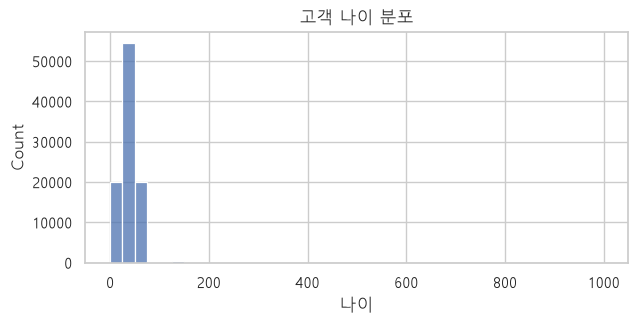

In [8]:
# ── 쓸 도구 ─────────────────────────────────────────
#   sorted(cu['age'].dropna().unique()) 로 고유값 정렬 후 [:5]·[-5:] · 개수는 (cu['age'] <
#     10).sum() · sns.histplot(값, bins=40) · plt.figure(figsize=(7, 3)) ·
#     plt.title()·plt.xlabel()·plt.show().

age_values = sorted(cu['age'].dropna().unique())
print('age 최솟값 5개:', [int(v) for v in age_values[:5]])
print('age 최댓값 5개:', [int(v) for v in age_values[-5:]])

age_count = ((cu['age'] < 10) | (cu['age'] > 100)).sum()
print('10세 미만:', (cu['age'] < 10).sum()) # 확인 o
print('100세 초과:', (cu['age'] > 100).sum()) # 확인 o

plt.figure(figsize=(7,3))
sns.histplot(cu['age'].dropna(), bins=40)
plt.title('고객 나이 분포')
plt.xlabel('나이')
# plt.yscale('log') # 이상치 확인
plt.show()

# 999·130 때문에 x축이 1000까지 늘어나 실제 나이대(0~100)가 3칸에 뭉개짐
# -> 극단값 2개가 분포 자체를 못 읽게 만든다

### 3-2. 이상치를 규칙으로 잡아보기 — IQR · Z-score (day08)
통계 규칙이 이상치를 **자동으로** 걸러 줄 것 같지만, 이 데이터에서는 그렇지 않습니다. 직접 계산해 확인하세요.

**직접 작성 — IQR·Z-score 를 `age` 에 적용해 보기**

**할 일**: ① IQR 1.5배 규칙의 정상 범위와 그 밖으로 잡히는 인원 ② `|z| > 3` 에 걸리는 인원 ③ 두 규칙이 각각 **10세 미만 921명 중 몇 명을 잡는지**와 **나이 999 의 z 값**.

**확인 기준**

| 확인할 것 | 값 |
| --- | --- |
| IQR 정상 범위 | 약 **-9.5 ~ 82.5** (하한이 **음수**) |
| IQR 이 잡는 이상치 | 602명 (전부 82.5세 초과) |
| Z-score 가 잡는 이상치 | 279명 |
| 10세 미만 921명 중 IQR / Z-score 가 잡는 수 | **0명 / 0명** |
| 나이 999 의 z | 약 **17.8** |

**이 결과가 말하는 것**: IQR 하한이 음수라 0세·3세가 정상 범위로 통과하고, 999 같은 극단값이 표준편차를 부풀려 Z-score 기준까지 무디게 만듭니다. **큰 이상치는 규칙이 잡지만 "10세 미만은 쇼핑 고객일 수 없다" 같은 도메인 판단은 규칙이 대신하지 못합니다** — 둘을 함께 써야 합니다.

**함정**: 판다스 `.std()` 는 표본 표준편차, 넘파이 `np.std()` 는 모표준편차라 값이 다릅니다 (위 기준은 판다스).

In [9]:
# ── 쓸 도구 ─────────────────────────────────────────
#   cu['age'].quantile([0.25, 0.75]) 로 1·3사분위 -> 범위는 1사분위 - 1.5 x IQR ~ 3사분위 +
#     1.5 x IQR · 범위 밖은 두 조건을 | 로 묶어 셉니다 · z 는 (값 - .mean()) / .std() 에
#     .abs() · 겹쳐 세려면 & · 특정 값의 z 는 z[cu['age'] == 999].iloc[0].

q1, q3 = cu['age'].quantile([0.25, 0.75])
iqr = q3 - q1
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr
print(f"IQR 범위: {lower:.1f} ~ {upper:.1f}")

iqr_count = ((cu['age'] < lower) | (cu['age'] > upper))
print(f'IQR 범위를 벗어난 이상치 인원 수: {iqr_count.sum()}명')

z = ((cu['age'] - cu['age'].mean()) / cu['age'].std()).abs()
z_count = z > 3
print(f"|z|>3에 걸리는 인원 수: {z_count.sum()}명")

print('10세 미만 중 IQR이 잡은 수:', ((cu['age'] < 10)&iqr_count).sum(),'명') # 0명
print('10세 미만 중 Z-score이 잡은 수:', ((cu['age'] < 10)&z_count).sum(), '명') # 0명

print('나이 999의 z값: 약', z[cu['age'] == 999].iloc[0].round(1))
print('나이 0의 z값: 약', z[cu['age'] == 0].iloc[0].round(1))

# IQR: 하한이 음수(-9.5)라 아래쪽 값은 못 거른다.
# Z-score: 평균에서 표준편차 몇 칸 떨어졌나. 999세는 17.8칸 -> 확실한 이상치.
#          0세는 0.72칸. 999 때문에 표준편차가 53.9로 커져 한 칸이 넓어진 탓.
#          |z|<3 이라 규칙상 정상으로 통과하지만 실제로는 이상치다.
# -> 통계 규칙은 큰 이상치만 잡는다. 10세 미만은 도메인 판단으로 걸러야 한다.

IQR 범위: -9.5 ~ 82.5
IQR 범위를 벗어난 이상치 인원 수: 602명
|z|>3에 걸리는 인원 수: 279명
10세 미만 중 IQR이 잡은 수: 0 명
10세 미만 중 Z-score이 잡은 수: 0 명
나이 999의 z값: 약 17.8
나이 0의 z값: 약 0.7


### 3-3. 이상치 ② 가격 0 이하

**할 일**: `tr['price']` 가 **0 이하인 건수**를 세고 `price` 요약 통계를 출력하세요.

**왜**: 결제금액이 핵심 지표입니다. 0 이하가 섞이면 평균 단가와 합계가 함께 왜곡됩니다.

**확인 기준**: **1,004건**.

**함정**: `< 0` 으로 세면 **0건**이 나옵니다 — 이 데이터의 문제 건은 정확히 **0원**이라 `<= 0` 이어야 합니다.

In [10]:
# ── 쓸 도구 ─────────────────────────────────────────
#   (tr['price'] <= 0).sum() · tr['price'].describe().

price0 = tr['price'] <= 0
print('가격이 0원 이하인 이상치:', price0.sum(), '건')

tr['price'].describe()

가격이 0원 이하인 이상치: 1004 건


count    150500.000000
mean          0.027554
std           0.019348
min           0.000000
25%           0.015237
50%           0.025407
75%           0.033881
max           0.422034
Name: price, dtype: float64

### 3-4. 이상치 ③ 정의에 없는 채널 코드 · 결측치 ① 멤버십

**할 일**: ① `tr['sales_channel_id']` 의 고유값을 정렬해 보고(1 = 오프라인, 2 = 온라인 — 그럼 나머지는?) 정의에 없는 코드의 건수를 세세요. ② `cu['club_member_status']` 의 **결측 인원**과 **`LEFT CLUB`(탈퇴) 인원**을 세세요.

**왜**: 정의에 없는 코드는 분석 축으로 쓸 수 없습니다(범주가 하나 늘어 집계표가 어긋납니다). 탈퇴 고객을 넣을지는 목적에 따라 갈리는 판단입니다.

**확인 기준**: 채널 코드 **`[0, 1, 2]`** 이고 **0 이 803건** · 멤버십 **결측 2,500명** · **`LEFT CLUB` 40명**.

**함정**: 결측은 `== None`·`== np.nan` 으로 셀 수 없습니다(자기 자신과도 같지 않아 항상 0) — `.isna()` 를 쓰세요.

In [11]:
# ── 쓸 도구 ─────────────────────────────────────────
#   sorted(tr['컬럼'].unique()) · (tr['컬럼'] == 0).sum() · cu['컬럼'].isna().sum() ·
#     (cu['컬럼'] == 'LEFT CLUB').sum().

cnl_values = sorted(tr['sales_channel_id'].unique().tolist())
print(f'채널코드: {cnl_values}')

channel0 = (tr['sales_channel_id'] == 0).sum().tolist()
print(f'채널코드 0의 건수: {channel0}건')

mbr_values = cu['club_member_status'].isna().sum()
print(f'멤버십 결측 인원 수: {mbr_values:,}명')

lc_count = (cu['club_member_status'] == 'LEFT CLUB').sum()
print(f'LEFT CLUB 인원 수: {lc_count}명')

채널코드: [0, 1, 2]
채널코드 0의 건수: 803건
멤버십 결측 인원 수: 2,500명
LEFT CLUB 인원 수: 40명


### 3-5. 결측치 ② 채우는 방법 세 가지 비교 — `fillna` vs `ffill`/`bfill`
결측을 채우는 방법은 하나가 아니고, **어느 것이 맞는지는 데이터의 성격이 결정합니다.** 직접 비교해 확인하세요.

**직접 작성 — 결측 채우는 세 방법 비교**

**할 일**: `cu['club_member_status']` 를 **복사**해 세 방법(상수 `'Unknown'` · 앞 값 · 뒤 값)을 각각 적용하고, 원본과 세 결과의 **남은 결측 개수**를 비교해 출력하세요.

**확인 기준**: 원본 **2,500명** → 상수 **0** · `bfill` **0** · `ffill` **1명 남음**.

**이 결과가 말하는 것**: `ffill` 에 1명이 남는 것은 **맨 첫 행이 결측**이라 참고할 앞 값이 없기 때문입니다. 그리고 `cu` 는 고객이 **무작위 순서로 나열된 표**라서 "앞/뒤 고객의 멤버십"에는 아무 의미가 없습니다 — **순서에 의미가 없는 속성 데이터에는 상수 채우기**, `ffill`·`bfill` 은 센서 로그처럼 **순서 자체가 의미일 때** 쓰는 도구입니다.

**함정**: `.copy()` 없이 채우면 `cu` 가 실제로 바뀌어 뒤의 확인과 5장 결합까지 오염됩니다.

In [12]:
# ── 쓸 도구 ─────────────────────────────────────────
#   .copy() · .fillna('Unknown') · .ffill() · .bfill() · .isna().sum().

club = cu['club_member_status'].copy()

# print(club) # 0번째 행 결측 확인됨 -> ffill해도 결측 1개 남아있음

club_unknown = club.fillna('Unknown')
club_ffill = club.ffill()
club_bfill = club.bfill()

print('원본:', club.isna().sum())
print('Unknown fill:', club_unknown.isna().sum())
print('ffill:', club_ffill.isna().sum())
print('bfill:', club_bfill.isna().sum())

원본: 2500
Unknown fill: 0
ffill: 1
bfill: 0


**데이터를 읽을 때 함께 알아둘 것**

| 함정 | 무엇을 조심하나 |
| --- | --- |
| **매출 계산** | `tr` 에 **수량(quantity) 컬럼이 없습니다.** `price` 합계는 매출이 아니라 **"구매 단가의 총합"** 입니다 |
| **통화·단위** | 원 통화 금액이 아니라 **정규화된 상대값**(0 ~ 0.422)입니다. 어떤 통화로도 환산하지 말고 **상대 비교에만** 쓰세요 |
| **시간** | `t_dat` 는 아직 문자열입니다. 월·요일 파생 전에 **`pd.to_datetime` 변환이 먼저**입니다. 기간은 2019년 1년치라 **연도 간 비교는 불가능**합니다 |
| **표본 편향** | H&M 전체가 아니라 **공개 표본**이고 **온라인 기록이 상대적으로 많습니다**(온라인 103,836건 vs 오프라인 45,861건). 채널 비중을 비교할 때 이 편향 때문에 **온라인이 커 보이는 것**일 수 있으니, 건수만으로 "온라인이 우세하다"고 단정하지 마세요 |
| **시즌성** | 특정 월의 급증이 **연말·행사 효과**일 수 있습니다. 한 달 치가 높다고 "성장"으로 단정하지 마세요 |

**여기까지 되면 통과**: 3-1 ~ 3-5 의 출력을 모두 확인했으면 됩니다(이 장은 채점하지 않습니다 — 눈으로 확인하는 것 자체가 목표).

### 3-6. 이상치의 두 층위 — 값 수준 vs 개체 수준
3장에서 본 것은 모두 **값 수준**(컬럼 하나의 값이 이상한가)입니다. 값은 하나하나 정상인데 **그 조합이나 합계가 이상한** 경우가 따로 있습니다.

| 층위 | 무엇을 보는가 | 이 데이터의 예 | 찾는 방법 |
| --- | --- | --- | --- |
| **값 수준** | 컬럼 하나의 값 | 나이 999, 가격 0, 채널 0 | 3-1 ~ 3-4 에서 한 것 |
| **개체 수준** | 한 고객 / 한 거래를 통째로 | 1년에 수백 건을 산 고객 | 고객별로 묶어 구매 건수·총 결제금액의 분포에서 극단값을 찾는다 |

개체 수준 이상치는 **사람이 아닐 수도 있습니다**(재판매업자·기업 구매·중복 기록). 그런 몇 명이 평균을 끌어올리면 "우리 고객은 1년에 평균 몇 건 산다" 가 통째로 틀립니다.

> 개체 수준 탐색은 고객별 집계가 필요하니 **02 에서** 합니다. 지금은 4장 결정 기록표에 **어떻게 다룰지 한 줄만** 정해 두세요 — "남겨 두고 02 에서 확인한다" 도 정당합니다. **정하지 않는 것만 문제입니다.**

## 4장. 전처리 규칙 수립 — 항목별로 어떻게 처리할지 정한다
**할 일**: 3장에서 센 것들을 **어떻게 처리할지 고르고 이유를 적습니다.** 코드는 6장에서 적용합니다. **"정답"은 없고, 이유 없는 선택만 문제입니다.**

### 4-1. 정제 — 완전 중복 행 · 자료형

| 항목 | 어떻게 처리하나 | 판단 |
| --- | --- | --- |
| 완전 중복 행 | `drop_duplicates()` 로 제거 / 그대로 유지 | 이 데이터엔 **수량 컬럼이 없어** 정상 재구매와 입력 오류를 구분할 수 없습니다. 제거가 무난하지만 근거를 적으세요 |
| `t_dat` 자료형 | `pd.to_datetime` 으로 날짜형 변환 | **선택이 아닙니다** — 월·요일 파생을 하려면 반드시 먼저 해야 합니다 |

> 완전 중복 행은 **결합 후에만** 판단할 수 있습니다. 거래 한 줄만으로는 진짜 중복인지 알 수 없고, 고객·상품 정보까지 붙은 완전한 행이라야 비교가 됩니다 → 6장.

### 4-2. 결측치 처리 — 멤버십(`club_member_status`)
결측 **2,500명**, `LEFT CLUB`(탈퇴) **40명**.

| 처리 방법 | 트레이드오프 |
| --- | --- |
| **별도 범주로 채우기** — `fillna('Unknown')` | 행을 지키고 "모른다"도 정보로 남김 / 결측의 원인은 여전히 모름 |
| **행 제거** | 확실한 값만 남음 / 표본이 줄고, 결측이 무작위가 아니면 편향됨 |
| 최빈값 등으로 대체 | 결측이 사라짐 / 관측되지 않은 값을 넣는 것이라 멤버십별 분석 근거가 약해짐 |

> **`LEFT CLUB` 포함 여부를 반드시 명시하세요.** 탈퇴 전 구매도 실제 있었던 거래이니 **매출을 볼 때는 포함**이 자연스럽고, "지금 회원은 어떻게 행동하나" 를 볼 때는 **제외**가 맞습니다. 목적에 따라 갈립니다.

### 4-3. 이상치 처리 — 나이 · 가격 · 채널 코드 · 개체 수준

**① 나이(`age`)** — 0·3·7·130·999 가 섞여 있고, 3-2 에서 봤듯 **통계 규칙만으로는 10세 미만을 하나도 못 걸러냅니다.**

| 처리 방법 | 트레이드오프 |
| --- | --- |
| **제거** — 범위만 남기기(예: `between(10, 99)`) | 단순하고 설명하기 쉬움 / 경계값이 다소 자의적 |
| **누르기(clip)** — 상·하한으로 압축 | 행 손실 없음 / 없던 값이 실제처럼 보임 |
| **결측 처리 후 대체** — 중앙값 등 | 표본 유지 + 극단값 영향 제거 / 관측 안 된 값이라 근거 약함 |
| **유지** | 정보 손실 없음 / 평균·표준편차가 크게 흔들림 |

> **`age_group` 파생은 이 결정 다음입니다.** 순서를 뒤집으면 999세가 90대 그룹으로 섞입니다.

**② 가격(`price`) 0 이하** — **1,004건**. 무료 배포인지 오류인지 환불인지 **데이터만으로는 알 수 없습니다.**

| 처리 방법 | 트레이드오프 |
| --- | --- |
| **제거** | 집계가 단순해짐 / 사은품 같은 정상 거래까지 지울 수 있음 |
| **플래그 + 유지** — `is_free` 참/거짓 컬럼 | 포함·제외 결과를 **둘 다** 볼 수 있음(실무에서 자주) / 컬럼이 늘고 집계마다 판단이 필요 |
| 대체(평균·중앙값) | 행 보존 / 0원이 정말 결측인지 알 수 없어 부정확 |
| 유지 | 정보 손실 없음 / 평균 단가·합계가 낮게 왜곡됨 |

**③ 채널 코드 0 (803건)** — 정의(1·2)에 없는 값이라 **분석 축으로 쓸 수 없습니다.** 제거하거나 별도 범주로 묶되, 803건을 버리는 것임을 적어 두세요.

**④ 개체 수준 이상치** — 3-6 참고. 지금은 "어떻게 다룰지" 한 줄만 정하고 탐색은 02 에서.

### 4-4. 처리 순서
**정제 → 결측치 → 이상치 → 파생** 순서를 지키세요. 이유는 두 가지입니다.

- **파생보다 이상치 제거가 먼저**: `age_group` 을 먼저 만들면 999세도 엉뚱한 그룹으로 섞여 이후 집계가 왜곡됩니다.
- **완전 중복 제거는 결합 이후**: 거래 한 줄만으로는 진짜 중복 구매인지 알 수 없습니다.

나이·멤버십처럼 **한 테이블에만 있는 컬럼**은 결합 전에 걸러도 후에 걸러도 결과가 같습니다.

### 4-5. 결정 기록표 (직접 채우세요)
**요구사항**: **내 선택·이유·잃은 것**을 모두 채우세요. 규칙이 무엇이든 상관없고 **이유가 없으면 통과가 아닙니다.**

| 갈래 | 항목 | 내 선택 | 이유 | 잃은 것 |
| --- | --- | --- | --- | --- |
| 정제 | 완전 중복 행 | 제거 | 수량 컬럼이 없어 정상 재구매와 입력 오류를 구분할 수 없고, 중복이면 결제금액이 이중 계산되는 문제가 있다. | 같은 날+같은 상품을 실제로 여러 개 산 정상 거래 |
| 결측치 | 멤버십 결측·LEFT CLUB | 결측: Unknown 유지 / 탈퇴: 제외 | 멤버십만 모를 뿐 나이·채널·가격은 관측된다. 핵심 질문 3개가 멤버십을 쓰지 않아 버릴 이유가 없고, 상태 미확인 고객은 온보딩 프로모션 대상 후보이다. / 마케팅 프로모션은 현재 회원의 행동을 기준으로 설계해야 한다. | 결측이 생긴 진짜 원인은 여전히 모른다. / 탈퇴 전 구매 53건 |
| 이상치 | 나이 | 제거 (10세~99세) | IQR 하한이 −9.5라 10세 미만 921명을 0명 검출하고, Z-score도 0명이었다. → 통계 규칙으로는 불가능하여 "쇼핑 고객으로 가능한 나이"라는 도메인 기준을 적용했다. 프로모션 타겟 연령대를 명확히 하려면 필수이기 때문이다. | 실제 존재했을 수 있는 100세 이상 고객 |
| 이상치 | 가격 0 이하 | 플래그+유지 | 사은품 같은 정상거래를 지우게되면 프로모션 전략 수립이 어려워진다. | 플래그만 만들고 실제로 쓰지 않으면 그냥 "유지"와 같아져서 평균 단가가 1,004건만큼 낮게 왜곡될 가능성이 있다. |
| 이상치 | 채널 코드 0 | 별도 범주로 묶기, 단 채널을 분석축으로 쓸 때는 제외 | 채널 정보가 없어도 그 거래의 나이·가격은 유효해서 연령대·시즌성 분석엔 쓸 수 있다. 반면 채널 비교(질문 1)에서는 정의 없는 범주라 해석이 불가능하다. | 803건에 대해 집계마다 포함 여부를 따로 판단해야 한다. |
| 이상치 | 개체 수준(고객·거래) | 제거하지 않고 유지, 02 에서 고객별 총구매액 상위 20% 분석 시 재확인 | 고객당 구매가 평균 1.22건, 최대 11건으로 재판매업자급 극단 고객이 없어 평균을 왜곡할 위험이 낮다. 프로모션 타겟을 정할 때 소수 헤비유저에 평균이 끌려가는 문제도 이 규모에선 작다. | 소수 다구매 고객이 상품군별 집계에 미치는 영향은 남아 있다. |`

** 온보딩 프로모션: 새 고객을 정식 회원으로 자리잡게 만드는 초기 유도 활동 (ex. 첫 구매 쿠폰, 웰컴 혜택 등)

**여기까지 되면 통과**: 여섯 항목 모두 **선택과 이유**가 채워져 있으면 됩니다. 코드 적용은 6장에서 합니다.

## 5장. 테이블 결합
**이 절에서 할 일**: `customer_id`·`article_id` 로 세 테이블을 하나로 합쳐 분석용 데이터셋을 만듭니다. 결합 함수가 기억나지 않으면 day06 교안에서 찾아보세요.

**`inner` vs `left`** — `how='inner'` 는 **양쪽에 모두 키가 있는 행만** 남기고, `how='left'` 는 **왼쪽을 전부 남기고** 오른쪽 정보가 없으면 결측으로 채웁니다. 이 프로젝트는 고객·상품 정보가 **반드시 있어야** 이후 분석(연령대·상품군 비교 등)이 가능하므로 **`inner`** 로 결합합니다(고객·상품 정보가 없는 거래는 애초에 분석 대상이 아니라고 보는 선택입니다).

> **그럼 `left` 는 언제 필요한가** — 질문이 바뀌면 조인도 바뀝니다. 대표적인 경우가 "**가입은 했지만 한 번도 구매하지 않은 고객**은 몇 명인가?" 입니다. 이건 고객 테이블을 **왼쪽에 두고** 거래를 `left` 로 붙여야 보입니다 — 구매 기록이 없는 고객이 결측 행으로 남기 때문입니다. `inner` 로는 그 고객들이 조용히 사라져 애초에 없었던 것처럼 됩니다.
> 다만 **이 데이터에서 그 답은 0명**입니다(고객 테이블의 95,516명이 모두 거래에 등장합니다). "발제문에 나온 주의사항이 내 데이터에도 해당되는지"는 **직접 확인해야 알 수 있습니다** — 이것도 여러분이 검증해 볼 만한 질문입니다.
> 대신 이 데이터에는 **반대 방향의 손실**이 있습니다. `inner` 로 결합하면 거래 150,500건 중 **33,527건(22.3%)이 사라집니다** — 그 거래를 한 고객이 고객 테이블에 없기 때문입니다(거래에는 123,053명이 등장하는데 고객 테이블에는 95,516명뿐입니다). 즉 이 프로젝트가 `inner` 를 고르는 순간 **"고객 정보를 아는 거래만 분석한다"** 고 선언하는 것이고, 그래서 여기서 계산할 매출은 **전체 매출이 아닙니다.** 전체 거래 금액을 보고 싶다면 거래를 왼쪽에 두고 `left` 로 붙여 나이·멤버십을 결측으로 남기는 편이 맞습니다.
> 이 노트북의 정제본은 "고객·상품 정보가 붙은 구매 1건"을 관측단위로 하므로 `inner` 로 만듭니다(자가채점도 그 기준입니다). **조인 방식은 질문이 정한다** — 이것이 이 절의 핵심이고, 무엇을 골랐든 **몇 건이 왜 빠졌는지 적어 두는 것**이 요구사항입니다.

> **모든 테이블을 반드시 결합할 필요는 없습니다.** 분석 목적에 따라 조인 범위를 줄이는 것이 오히려 낫습니다 — 예를 들어 "연령대별 구매 패턴" 만 볼 거라면 거래 + 고객 두 개로 충분하고, 상품 25컬럼을 붙이면 메모리만 쓰고 얻는 게 없습니다. 이 노트북은 02·03 이 상품군 분석까지 하므로 세 개를 다 붙입니다.

**결합 후 행 증가 여부 검증** — merge 는 키가 중복되면 행이 **늘어날 수도** 있습니다. `cu`·`ar` 의 키(`customer_id`·`article_id`)가 각각 유니크한지 미리 확인하면, 결합 후 행수가 예상 밖으로 튀지 않는다는 것을 보장할 수 있습니다.

**중복 컬럼 확인** — 두 테이블을 합칠 때 이름이 겹치는 컬럼이 있으면 pandas 가 `_x`/`_y` 접미사를 붙입니다. 미리 `set(a.columns) & set(b.columns)` 로 확인하는 습관을 들이면 좋습니다.

아래 두 지침을 따라 **검증 -> 결합** 순서로 코드를 직접 쓰세요.

**직접 작성 — 결합 전 검증**

**할 일**: `cu` 의 `customer_id` 와 `ar` 의 `article_id` 가 각각 **유니크한지** 확인하고, 세 테이블 사이에 **이름이 겹치는 컬럼**이 무엇인지 세 쌍(`tr`·`cu` / `tr`·`ar` / `cu`·`ar`) 모두 출력하세요.

**왜**: 붙이는 쪽 키가 중복이면 결합 결과 행이 불어납니다. 미리 확인해 두면 결합 후 행수가 튀지 않았다고 **말할 수 있게** 됩니다.

**확인 기준**: 두 키 모두 `True`, 겹치는 컬럼은 **키뿐** — `tr`·`cu` 는 `{'customer_id'}`, `tr`·`ar` 는 `{'article_id'}`, `cu`·`ar` 는 **빈 집합**. 그래서 결합 후 `_x`/`_y` 접미사가 생기지 않습니다.

> 발제문은 "`article_id` 결합 시 중복 컬럼을 제거하라"고 경고하는데, **이 데이터에는 겹치는 컬럼이 없어 지울 것이 없습니다.** 겹쳤다면 `prod_name_x`·`prod_name_y` 로 갈라지므로 같은 값인지 확인한 뒤 하나를 `drop` 해야 합니다 — 그래서 결합 **전에** 확인합니다.

**함정**: `is_unique` 는 괄호를 붙이지 않는 **속성**입니다(`.is_unique()` 로 부르면 에러). 그리고 `tr` 의 `customer_id` 는 유니크하지 **않습니다**(한 고객이 여러 번 구매) — 확인해야 하는 쪽은 **붙이는 오른쪽 테이블**의 키입니다.

In [13]:
# ── 쓸 도구 ─────────────────────────────────────────
#   df['컬럼'].is_unique · 컬럼 겹침은 set(a.columns) & set(b.columns).

cus_unq = cu['customer_id'].is_unique
print(cus_unq)

art_unq = ar['article_id'].is_unique
print(art_unq)

name_dupli_1 = set(tr.columns) & set(cu.columns)
print(name_dupli_1)
name_dupli_2 = set(tr.columns) & set(ar.columns)
print(name_dupli_2)
name_dupli_3 = set(cu.columns) & set(ar.columns)
print(name_dupli_3) # 빈 집합

True
True
{'customer_id'}
{'article_id'}
set()


**직접 작성 — 세 테이블 결합**

**할 일**: 거래(`tr`)를 기준으로 고객(`cu`)·상품(`ar`) 정보를 **`inner` join** 으로 붙여 **`df`** 라는 이름의 분석용 데이터셋을 만들고, **결합 전 행수 -> 결합 후 행수**와 최종 `shape` 를 출력하세요(앞부분 몇 행도 함께 확인하세요).

> ⚠️ **변수 이름은 `df` 여야 합니다.** 바로 다음 자가채점 셀과 6·7장, 그리고 02·03 노트북이 모두 이 이름을 씁니다.

**왜**: 연령대별·상품군별 분석을 하려면 거래 한 줄에 그 고객의 나이와 상품 정보가 함께 붙어 있어야 합니다.

**확인 기준**: **150,500행 -> 116,973행 x 34열**(다음 자가채점 셀이 검사). 34열 = 거래 5 + 고객 6 + 상품 25 - 중복 키 2.

**함정**
- 행이 **33,527건 줄어드는 것은 정상**입니다(고객 테이블에 없는 고객의 거래). 줄어든 건수를 기록해 "몇 건이 왜 빠졌는지" 설명할 수 있게 하세요.
- 결합 순서를 바꾸면 행수는 같아도 컬럼 순서가 달라집니다 — 거래를 왼쪽에 두고 고객 -> 상품 순.
- `how='left'` 로 하면 거래 150,500행이 전부 남고 고객·상품 정보가 없는 행은 결측이 되어 이후 연령대·상품군 분석이 어긋납니다. 이 프로젝트는 양쪽 정보가 **반드시 있어야** 하므로 `inner` 입니다.
- 행수가 150,500보다 **늘었다면** 오른쪽 키가 중복된 것입니다 — 앞 절의 검증으로 돌아가세요.

In [14]:
# ── 쓸 도구 ─────────────────────────────────────────
#   왼쪽.merge(오른쪽, on='키', how='inner') 를 두 번 이어 붙입니다 · 키는
#     customer_id · article_id · len(df) · df.shape.

df_joined = tr.merge(cu, on='customer_id', how='inner').merge(ar, on='article_id', how='inner')
df = df_joined.copy()

print(f"결합 후 행 수: {len(df):,}행")
print("결합 후 최종 shape: ", df.shape)

결합 후 행 수: 116,973행
결합 후 최종 shape:  (116973, 34)


In [15]:
# [자가채점]
assert df.shape == (116973, 34)
print("✅ 조인 직후 행수 확인 통과!")

✅ 조인 직후 행수 확인 통과!


**여기까지 되면 통과**: `df` 가 만들어지고 위 자가채점이 통과하면 됩니다.

## 6장. 전처리 규칙 적용 & 파생변수

**6-1. 전처리 실행** — 4장에서 정한 규칙을 `df` 에 적용하세요. 순서는 4-4 대로 **정제(완전 중복) → 결측치(멤버십) → 이상치(나이·가격·채널)** 입니다.

> **처리 로그를 남기세요** — 단계별 전후 행수를 `log` 리스트에 쌓아 마지막에 표로 출력합니다. "몇 건이 왜 빠졌는지"를 설명할 수 있어야 합니다.

> 4장에서 기준선(완전 중복 제거·나이 10~99·가격>0·채널 1·2·멤버십→Unknown)과 **다른 규칙**을 골랐다면 행수가 정답 예시본과 달라지는 것이 **정상**입니다.

> 💡 나이 범위는 `df['age'].between(10, 99)` 가 `(df['age'] >= 10) & (df['age'] <= 99)` 와 같은 결과를 내면서 더 읽기 쉽습니다.

<details><summary>힌트</summary>

```text
접근방법:
- 조건에 맞는 행만 남기는 필터를 순서대로 적용하고, 결측은 fillna 로 채운다.
- 매 단계 전후 len(df) 를 log 리스트(딕셔너리들)에 쌓고, 마지막에 pd.DataFrame(log) 로 표를 만들어 확인한다.

세부구현(예시 하나 — 그대로 안 써도 됩니다):
1. log = [] 로 시작한다
2. before = len(df) 를 찍고 df = df.drop_duplicates() 로 완전 중복 행을 제거한 뒤 log.append({...}) 로 기록한다
3. 같은 방식으로 age 범위 필터, price>0 필터, sales_channel_id isin 필터를 적용하고 각각 log 에 기록한다
4. club_member_status 의 결측을 정한 규칙대로 처리하고 log 에 기록한다
5. display(pd.DataFrame(log)) 로 처리 로그 표를 출력한다
```

</details>

In [16]:
df = df_joined.copy()

log = []

# 1. 정제 - 완전 중복 행
before = len(df)
df = df.drop_duplicates().copy()
log.append({'step': '완전 중복 행 제거', 'before': before, 'after': len(df),
            'removed': before - len(df), 'note': '수량 컬럼이 없어 정상 재구매와 입력오류 구분 불가, 이중계산 방지'})

# 2-1. 결측치 - 멤버십 결측
before = len(df)
df['club_member_status'] = df['club_member_status'].fillna('Unknown')
log.append({'step': '멤버십 결측 -> Unknown', 'before': before, 'after': len(df),
            'removed': before - len(df), 'note': '결측도 정보로 보존, 온보딩 대상 후보'})

# 2-2. 결측치 - LEFT CLUB
before = len(df)
df = df[df['club_member_status'] != 'LEFT CLUB'].copy()
log.append({'step': 'LEFT CLUB 제외한 행만 남기기', 'before': before, 'after': len(df),
            'removed': before - len(df), 'note': '현재 회원 행동 기준으로 프로모션 설계'})

# 3. 이상치 - 나이
before = len(df)
df = df[df['age'].between(10, 99)].copy()
log.append({'step': '나이 10~99 만 남김', 'before': before, 'after': len(df),
            'removed': before - len(df), 'note': 'IQR·Z-score 가 10세 미만 0명 검출 -> 도메인 기준 적용'})

# 4. 이상치 - 가격 0 이하 (플래그, 행 유지)
before = len(df)
df['is_zero_price'] = df['price'] <= 0
log.append({'step': '가격 0 이하 플래그', 'before': before, 'after': len(df),
            'removed': before - len(df), 'note': f"{df['is_zero_price'].sum()}건 표시만 — 사은품 가능성"})

# 5. 이상치 - 채널 코드 0 (유지)
before = len(df)
log.append({'step': '채널 코드 0 유지', 'before': before, 'after': len(df),
            'removed': before - len(df), 'note': f"{(df['sales_channel_id'] == 0).sum()}건 — 채널 분석 시에만 제외"})

display(pd.DataFrame(log))

,step,before,after,removed,note
0,완전 중복 행 제거,116973,116434,539,"수량 컬럼이 없어 정상 재구매와 입력오류 구분 불가, 이중계산 방지"
1,멤버십 결측 -> Unknown,116434,116434,0,"결측도 정보로 보존, 온보딩 대상 후보"
2,LEFT CLUB 제외한 행만 남기기,116434,116381,53,현재 회원 행동 기준으로 프로모션 설계
3,나이 10~99 만 남김,116381,114544,1837,IQR·Z-score 가 10세 미만 0명 검출 -> 도메인 기준 적용
4,가격 0 이하 플래그,114544,114544,0,769건 표시만 — 사은품 가능성
5,채널 코드 0 유지,114544,114544,0,611건 — 채널 분석 시에만 제외


**6-2. 파생변수 만들기** — **왜**: 02·03 이 연령대·시간대별 분석을 바로 할 수 있도록, 정제본에 미리 파생 컬럼을 심어 둡니다.

> 🔵 **스키마 계약 — 이 세 컬럼은 이름을 반드시 지켜야 합니다** (02·03 이 이 이름을 그대로 씁니다):
1. **`month`**(정수 1~12) — `t_dat` 를 `pd.to_datetime` 으로 날짜형으로 바꾼 뒤, `.dt.month`.
2. **`weekday`**(요일 **이름**, 예: `Monday`) — 같은 날짜형에서 `.dt.day_name()`.
3. **`age_group`**(정수, 10·20·…·90) — `age` 를 10살 단위로 묶습니다(`age // 10 * 10`, 정수형).

날짜 변환·파생 컬럼 만드는 법이 기억나지 않으면 day06 교안에서 찾아보세요.

<details><summary>힌트</summary>

```text
세부구현:
1. t_dat 를 to_datetime 으로 날짜형으로 변환해 다시 담는다
2. dt.month 로 month 컬럼을, dt.day_name() 으로 weekday 컬럼을 만든다
3. age 를 10 으로 정수 나눗셈한 뒤 10 을 곱하고 정수형으로 바꿔 age_group 을 만든다
```

</details>

In [17]:
df['t_dat'] = pd.to_datetime(df['t_dat'])
display(df['t_dat'])

df['month'] = df['t_dat'].dt.month
display(df['month'])

df['weekday'] = df['t_dat'].dt.day_name()
display(df['weekday'])

df['age_group'] = (df['age'] // 10 * 10).astype(int)
display(df['age_group'])

0        2019-01-01
1        2019-01-01
2        2019-01-01
3        2019-01-01
4        2019-01-01
            ...    
116573   2019-12-31
116574   2019-12-31
116575   2019-12-31
116576   2019-12-31
116577   2019-12-31
Name: t_dat, Length: 114544, dtype: datetime64[ns]

0          1
1          1
2          1
3          1
4          1
          ..
116573    12
116574    12
116575    12
116576    12
116577    12
Name: month, Length: 114544, dtype: int32

0         Tuesday
1         Tuesday
2         Tuesday
3         Tuesday
4         Tuesday
           ...   
116573    Tuesday
116574    Tuesday
116575    Tuesday
116576    Tuesday
116577    Tuesday
Name: weekday, Length: 114544, dtype: object

0         30
1         20
2         30
3         50
4         40
          ..
116573    40
116574    50
116575    40
116576    20
116577    20
Name: age_group, Length: 114544, dtype: int64

In [18]:
display(df[['t_dat', 'month', 'weekday', 'age', 'age_group']].head())
print(df[['month', 'weekday', 'age_group']].dtypes)

,t_dat,month,weekday,age,age_group
0,2019-01-01,1,Tuesday,30,30
1,2019-01-01,1,Tuesday,21,20
2,2019-01-01,1,Tuesday,35,30
3,2019-01-01,1,Tuesday,58,50
4,2019-01-01,1,Tuesday,46,40


month         int32
weekday      object
age_group     int64
dtype: object


**여기까지 되면 통과**: 처리 로그 표가 출력되고, `month`·`weekday`·`age_group` 세 컬럼이 만들어져 있으면 됩니다(행수는 규칙에 따라 달라도 정상입니다).

## 7장. 정제본 저장
**이 절에서 할 일**: 지금까지 정리한 `df` 를 CSV 로 저장합니다.

> 이 파일이 **02·03 의 입력**입니다. 여기까지 끝내야 다음 노트북이 돌아갑니다.
> **이 파일이 없으면 02·03 을 시작할 수 없습니다.** 02·03 은 이 파일을 여러분이 직접 불러오는 것으로 시작합니다 — 대신 만들어 주는 코드는 없습니다.

- **저장 경로**: `output/hm_clean.csv` (인덱스 없이, `index=False`).
- 저장 직전 `df` 의 shape·컬럼 목록을 출력하고, 저장한 뒤 **다시 읽어** 행수를 확인하는 코드를 직접 쓰세요.

> 🔒 저장 코드는 **`month`·`weekday`·`age_group` 세 파생 컬럼이 모두 있을 때만 저장**하도록 만드세요. 6장을 건너뛴 채 저장하면 정제되지 않은 데이터가 02·03 으로 흘러가 엉뚱한 분석 결과가 나오기 때문입니다. 저장이 안 됐다는 메시지가 보이면 6장으로 돌아가세요.
> 필터 규칙(나이·가격·채널·멤버십)은 **여러분의 선택**이므로 저장을 막을 조건이 아닙니다 — 남아 있는 항목은 알려만 주면 됩니다.

> 참고로 계약 기준선(완전 중복 제거 539행·나이 10~99·가격>0·채널 1·2·멤버십→Unknown)을 그대로 적용하면 최종 **113,218행 x 37열**(원본 조인 34열 + 파생 3열)이 됩니다. 여러분이 다른 규칙을 골랐다면 행수가 이 값과 달라지는 것이 정상입니다(이 저장 단계는 채점하지 않습니다) — 다만 **`month`·`weekday`·`age_group` 세 컬럼 이름은 그대로 유지**하세요.

**직접 작성 — 정제본 저장**

**할 일** — 세 단계를 한 셀에 담으세요.
1. 저장 직전 `df` 의 `shape` 와 **컬럼 목록**을 출력합니다.
2. **`month`·`weekday`·`age_group` 세 컬럼이 모두 있을 때만** `output/hm_clean.csv` 로 저장합니다. 하나라도 없으면 **저장하지 않고** 어떤 컬럼이 없는지와 6장으로 돌아가라는 안내를 출력합니다.
3. 저장했다면 그 파일을 **다시 읽어** 행수·컬럼이 그대로인지 확인합니다.

**왜**: 이 파일이 02·03 의 입력입니다. 6장을 건너뛴 채 저장하면 정제되지 않은 데이터가 다음 노트북으로 흘러갑니다.

**확인 기준**: 다시 읽은 shape 가 저장 직전과 같으면 됩니다. 4장 기준선을 그대로 적용했다면 **113,218행 x 37열**(다른 규칙이면 달라지는 것이 정상 — 채점하지 않습니다).

**함정**
- **`index=False` 를 빼면** 인덱스 컬럼이 하나 더 붙어 02·03 에서 38열이 되어 어긋납니다.
- 파생 컬럼 검사 없이 무조건 저장하면 6장을 안 한 **조인본(116,973행)이 정제본 자리를 차지**합니다.
- 필터 규칙은 **여러분의 선택**이라 저장을 막을 조건이 아닙니다 — 남은 항목은 알려만 주세요.
- **`month`·`weekday`·`age_group` 이름을 바꾸면 02·03 이 깨집니다.**

In [19]:
# ── 쓸 도구 ─────────────────────────────────────────
#   os.makedirs('output', exist_ok=True) · df.to_csv(경로, index=False) · 컬럼 확인은
#     'month' in df.columns · 다시 읽기는 pd.read_csv(경로) 후 .shape.

os.makedirs('output', exist_ok=True)

display(df.shape)
print('month' in df.columns)
print('weekday' in df.columns)
print('age_group' in df.columns)

df.to_csv('output/hm_clean.csv', index=False)

pd.read_csv('output/hm_clean.csv').shape

(114544, 38)

True
True
True


(114544, 38)

**다음 단계** — 정제본을 저장했다면 `02_데이터_EDA.ipynb` 로 넘어가세요. 그 노트북이 방금 저장한 `output/hm_clean.csv` 를 읽어 EDA·시각화를 진행합니다.